<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/06_ML_Dimentionality_Reduction/%20Genomics_cBioportal_mRNA_PCA%2CUMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Step 1: Data ko load karna
# (Using sep='\t' because the file is tab-separated)
df = pd.read_csv('data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt', sep='\t')

# (Checking the data size)
# (This will tell how many rows and columns there are)
print("Data shape:", df.shape)

# (Viewing the first 5 rows)
# (To see how the data looks)
print(df.head())

Data shape: (5131, 1982)
  Hugo_Symbol  Entrez_Gene_Id  MB-0362  MB-0346  MB-0386  MB-0574  MB-0185  \
0        RERE             473  -0.7139   1.2266  -0.0053  -0.4399  -0.5958   
1      RNF165          494470  -0.4606   0.3564  -0.6800  -1.0563  -0.0377   
2        PHF7           51533  -0.3325  -1.0617   0.2587  -0.2982  -1.2422   
3       CIDEA            1149  -0.0129  -1.0394   3.2991  -0.2632  -1.0949   
4       TENT2          167153  -0.7853   0.0337  -0.6649   2.1640  -0.2031   

   MB-0503  MB-0641  MB-0201  ...  MB-6192  MB-4820  MB-5527  MB-5167  \
0   0.4729   0.4974  -1.1900  ...  -0.4596   1.8975   1.1120   1.1942   
1  -0.6829  -0.2854  -0.4336  ...  -1.0927   0.9103  -0.0023  -0.2898   
2   0.0558  -0.5011  -0.6418  ...  -0.0725   0.7219   0.1402   0.8718   
3   1.2628   2.0796  -0.8310  ...   0.0679  -0.7126  -0.1523  -0.7593   
4   1.0304   0.6046  -1.7557  ...   0.6400  -0.1102   1.2719   0.8178   

   MB-5465  MB-5453  MB-5471  MB-5127  MB-4313  MB-4823  
0  -1.797

In [3]:
# Step 2: Data ko transpose karna aur missing values handle karna (Transposing and cleaning)
# PCA ke liye patients rows mein hone chahiye, isliye hum .T (transpose) use kar rahe hain
# Humne 'Hugo_Symbol' ko index banaya hai taaki sirf numbers par calculation ho
df_transposed = df.set_index('Hugo_Symbol').drop('Entrez_Gene_Id', axis=1).T

# Agar koi value missing hai (NaN), toh use column ke mean (average) se fill kar rahe hain
df_cleaned = df_transposed.fillna(df_transposed.mean())

# Ab naya shape check karte hain
print("New shape (Patients, Genes):", df_cleaned.shape)

New shape (Patients, Genes): (1980, 5131)


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 3: PCA run karna (Principle Component Analysis)
# (First, we scale the data so that all genes have equal weight)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

# (Initializing PCA - we are taking 2 components to create a graph)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# (Putting the result into a new dataframe)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

# (Checking the new shape of PCA data)
print("PCA shape:", pca_df.shape)

# PCA ke pehle 5 results dekhna
print(pca_df.head())


PCA shape: (1980, 2)
         PC1        PC2
0   0.865865  11.211724
1  -2.142943  -9.657630
2   7.198698  -0.338900
3  -2.158345  13.522393
4  12.432767  -6.255852


In [5]:
# Step 4:(Checking the Explained Variance Ratio)

# (This tells how much important information PC1 and PC2 have retained)
explained_variance = pca.explained_variance_ratio_

# (Printing to see the results)
print("PC1 information (Explained Variance):", explained_variance[0])
print("PC2 information (Explained Variance):", explained_variance[1])

# (How much total information is retained)
print("Total information (Total Variance retained by 2 components):", sum(explained_variance))

PC1 information (Explained Variance): 0.07604439938703447
PC2 information (Explained Variance): 0.05277578109716658
Total information (Total Variance retained by 2 components): 0.12882018048420105


In [6]:
# step 5:Install UMAP library)
!pip install umap-learn
import umap

# (Running UMAP)
# n_neighbors aur min_dist ko hum adjust kar sakte hain (We can adjust these parameters)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
umap_result = reducer.fit_transform(scaled_data)

# (Putting result into a dataframe)
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])

# (Checking the new shape)
print("UMAP shape:", umap_df.shape)
print(umap_df.head())


UMAP shape: (1980, 2)
      UMAP1     UMAP2
0  1.845781  3.529707
1  2.171704  4.253536
2  1.468105  4.292964
3  1.684058  3.277272
4  1.751417  4.405654


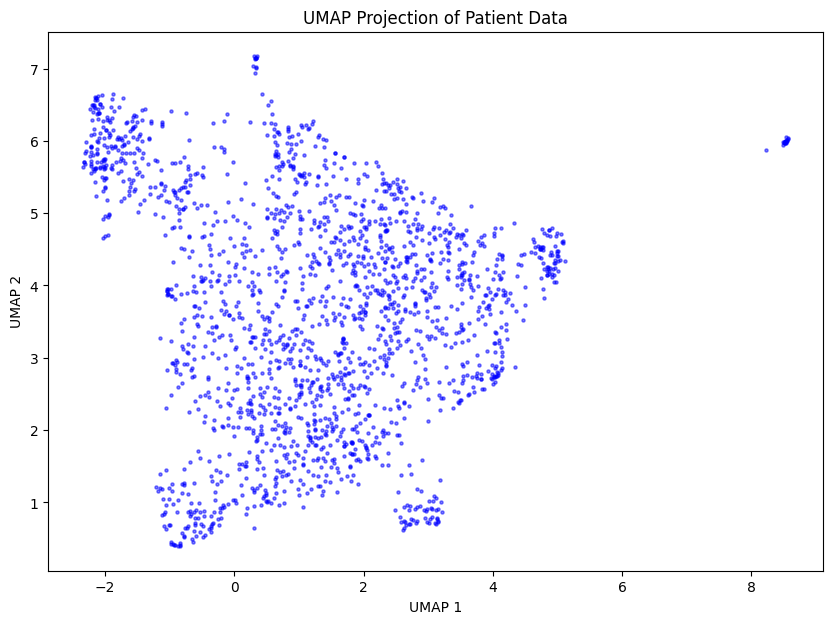

In [7]:
import matplotlib.pyplot as plt

# Step 6: Visualizing the UMAP results
# This code creates a scatter plot to see how patients are grouped
plt.figure(figsize=(10, 7))
plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=5, c='blue', alpha=0.5)

# Adding labels for better understanding
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Projection of Patient Data')

# Displaying the plot
plt.show()


In [10]:
from sklearn.feature_selection import VarianceThreshold

# Step 7: Feature Selection (VarianceThreshold)
# (Removing genes with very low variance as they don't provide much information)
selector = VarianceThreshold(threshold=0.1)
df_selected = selector.fit_transform(df_cleaned)

# (Checking how many genes remain)
print("Original shape:", df_cleaned.shape)
print("New shape (Feature selection:", df_selected.shape)

Original shape: (1980, 5131)
New shape (Feature selection: (1980, 5131)


In [11]:
# Step 8: Now perform PCA again on the full data to reduce dimensions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scaling the data again for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

# Reducing to 50 components, which usually captures most information
pca = PCA(n_components=50)
pca_data = pca.fit_transform(scaled_data)

print("PCA reduced data shape:", pca_data.shape)

PCA reduced data shape: (1980, 50)


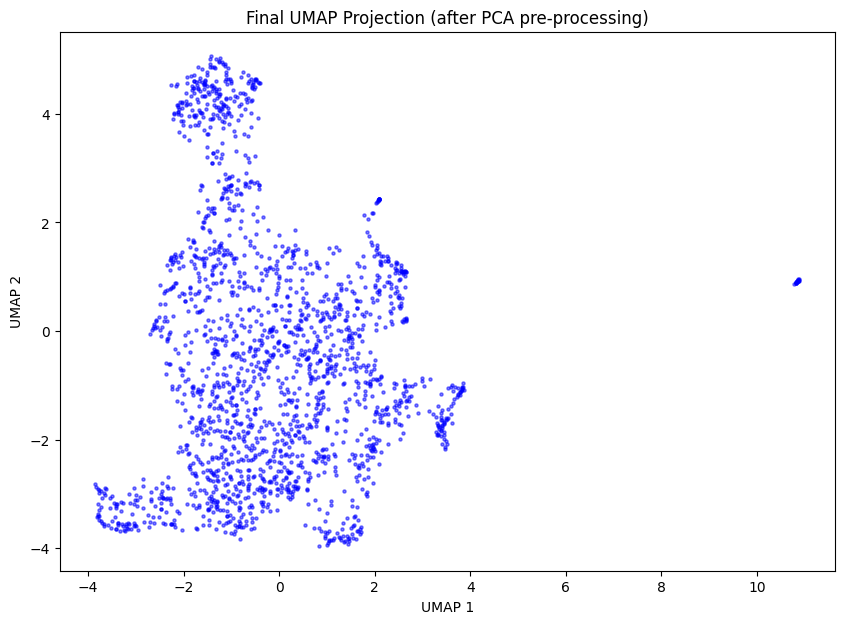

In [12]:
# Step 9: Running UMAP on the 50 PCA components
# (We are using pca_data here)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
umap_result = reducer.fit_transform(pca_data)

# Visualizing the final result
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(umap_result[:, 0], umap_result[:, 1], s=5, c='blue', alpha=0.5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('Final UMAP Projection (after PCA pre-processing)')
plt.show()


In [13]:
import pandas as pd

# UMAP result ko CSV mein save karna (Saving UMAP result to CSV)
umap_df.to_csv('umap_results.csv', index=False)
print("Result saved!")


Result saved!
